In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
import sys
sys.path.append('../robot')
from common import arena

In [3]:
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
# Remember that the edges are all defined in world coordinates.
low_probability = 10 ** -10
margin = 100

wx_range = np.arange(-margin, (arena.right - arena.left) + margin)
wy_range = np.arange(-margin, (arena.top - arena.bottom) + margin)
wx_map, wy_map = np.meshgrid(wx_range, wy_range, indexing='ij')

In [4]:
print("Wx range shape", np.shape(wx_range))
print("wx_map shape", np.shape(wx_map))

Wx range shape (1700,)
wx_map shape (1700, 1700)


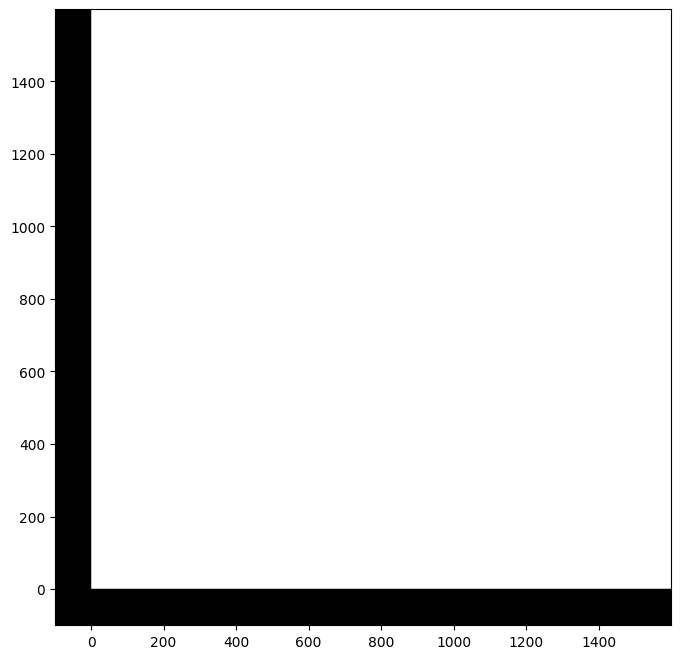

In [5]:
def plot_map(map_data, axs=None, title=None):
    if axs is None:
        plt.figure(figsize=(8, 8))
        axs = plt.gca()
    if title is not None:
        axs.set_title(title)
    axs.imshow(
        map_data.T,
        cmap='gray',
        origin='lower',
        extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
    )
plot_map((wx_map >= arena.left) & (wy_map >= arena.bottom))

In [6]:
edges = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
])

In [7]:
test_point = np.array([1100, 400])
test_point[::-1]

array([ 400, 1100])

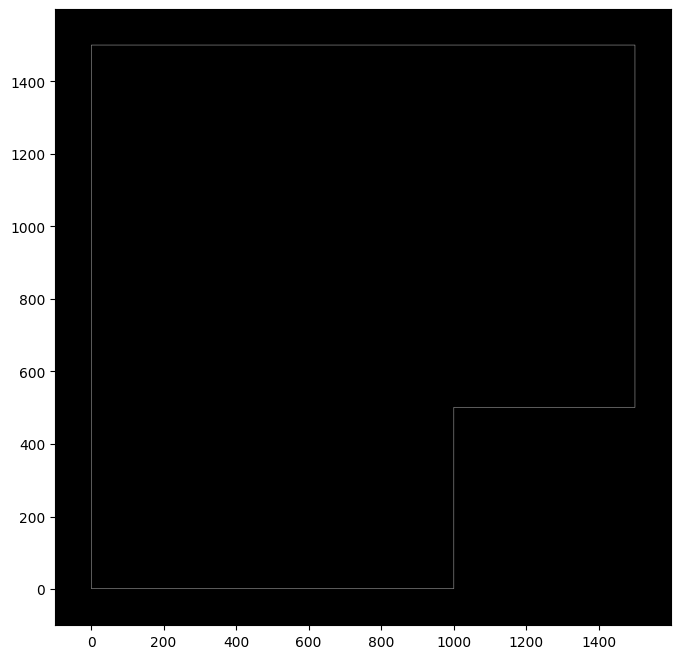

In [8]:
# Create the walls map with edges drawn as 1.0

walls_map = np.zeros_like(wx_map, dtype=np.float32)
for edge in edges:
    p1 = np.array(arena.walls[edge[0]]) + (margin, margin)
    p2 = np.array(arena.walls[edge[1]]) + (margin, margin)
    cv2.line(walls_map, p1[::-1], p2[::-1], color=1.0, thickness=1)

plot_map(walls_map)

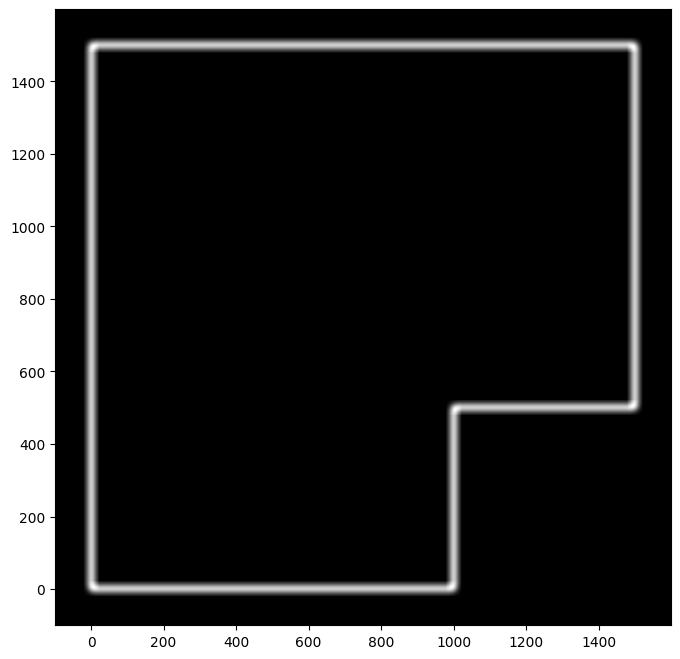

In [9]:
# Blur this map
distance_span = 41
blurred_distance = cv2.GaussianBlur(walls_map, (distance_span, distance_span), 10)
plot_map(blurred_distance)

In [10]:
def plot_zoomed(map_data, zoom_rect, axs=None, title=None):
    if axs is None:
        plt.figure(figsize=(8, 8))
        axs = plt.gca()
    if title is not None:
        axs.set_title(title)
    axs.set_xlim(zoom_rect[0], zoom_rect[2])
    axs.set_ylim(zoom_rect[1], zoom_rect[3])
    axs.imshow(
        map_data.T,
        cmap='gray',
        origin='lower',
        extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
    )

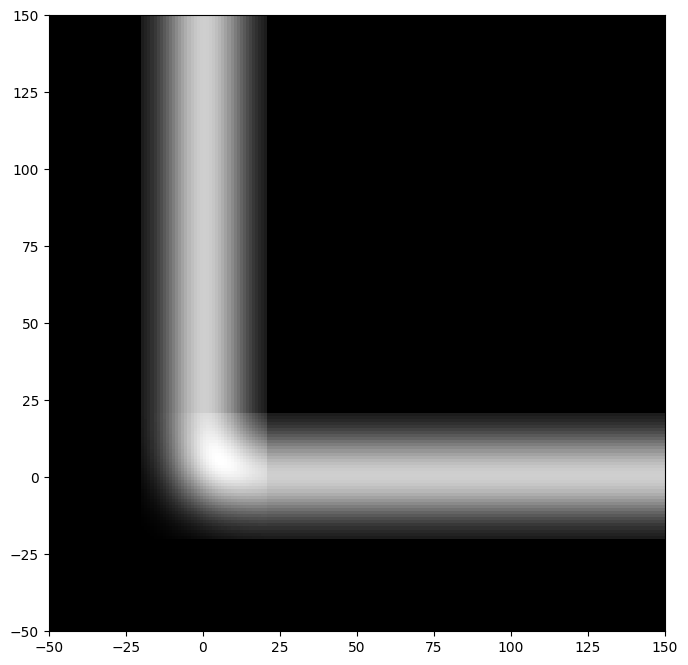

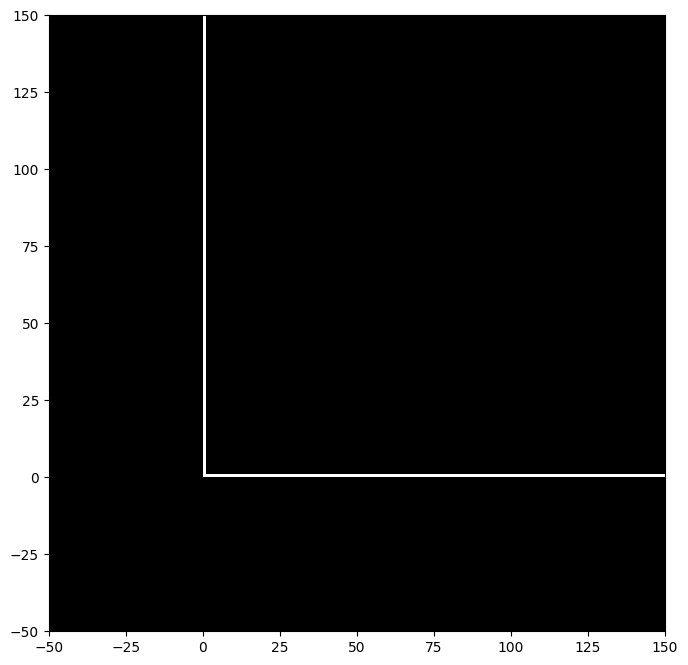

In [11]:
plot_zoomed(blurred_distance, [-50, -50, 150, 150])
plot_zoomed(walls_map, [-50, -50, 150, 150])

In [35]:
def wall_ridge_probability(walls_image, max_dist=None, soften_px=5, sigma_px=20):
    """
    walls_image: float32 or uint8; walls are "high"/nonzero, free is ~0.
    Returns distances in pixels as float32.
    """
    walls = (walls_image > 0).astype(np.uint8)        # 1 at walls
    inv   = (1 - walls).astype(np.uint8)              # 1 at free, 0 at walls

    # distance to nearest wall (0 pixel in inv)
    # dist = cv2.distanceTransform(inv, distanceType=cv2.DIST_L2, maskSize=5).astype(np.float32)
    dist = cv2.distanceTransform(inv, cv2.DIST_L2, cv2.DIST_MASK_PRECISE).astype(np.float32)
    dist_smooth = cv2.GaussianBlur(dist, (0, 0), soften_px)
    prob = low_probability + (1.0 - low_probability) * np.exp(-(dist_smooth**2) / (2.0 * sigma_px**2))
    return prob

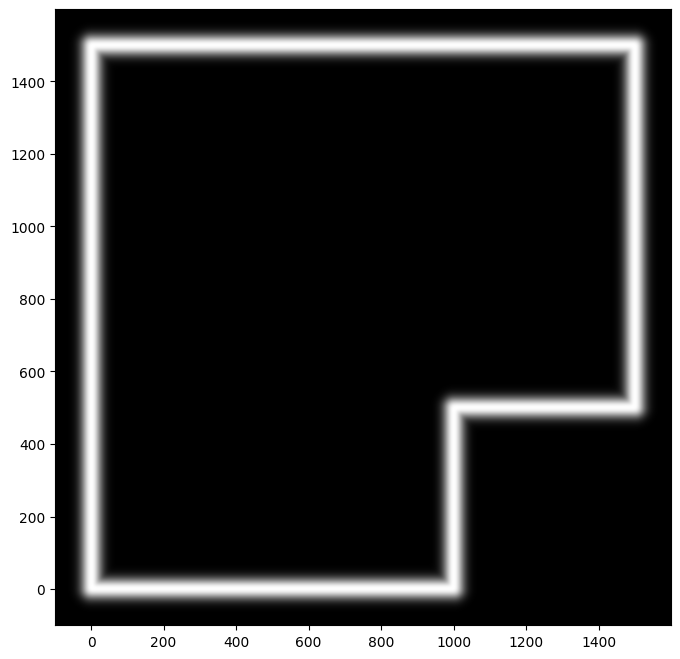

In [36]:
dist_image = wall_ridge_probability(walls_map)
plot_map(dist_image)

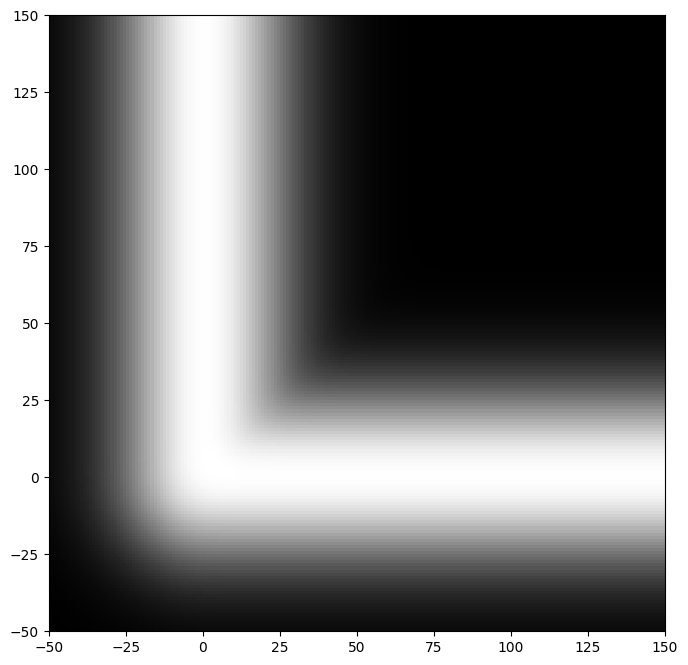

In [37]:
plot_zoomed(dist_image, [-50, -50, 150, 150])